2. Data Augmentation 

Apply augmentation techniques such as: 

• rotation 

• horizontal flip 

• zoom 

• width/height shift 

Train the CNN again and compare results.

In [1]:
# 1. Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Input
import matplotlib.pyplot as plt

2026-03-25 18:19:47.285520: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774462787.649714      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774462787.754231      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774462788.703383      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774462788.703418      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774462788.703421      55 computation_placer.cc:177] computation placer alr

In [2]:
# 2. Set Dataset Path
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"


In [3]:
# Image Augmentation (train only)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,          # reduced (faster)
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

#Faster config
IMG_SIZE = (128, 128)
BATCH_SIZE = 64

# Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'   #auto multi-class
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Check classes
print("Classes:", train_generator.class_indices)


Found 11229 images belonging to 6 classes.
Found 2805 images belonging to 6 classes.
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [4]:
#4. Load Test Data
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=64,
    #target_size=(150,150),
    #batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


In [5]:
#Build CNN Model
# Creates a Sequential model 
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774462849.144348      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774462849.150531      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
#6. Compile Model
model.compile(
    optimizer='adam', #faster than RMSprop
    loss='categorical_crossentropy', #correct for multi-class
    metrics=['accuracy']
)

In [7]:
# 7. Train Model
history = model.fit(
    train_generator,
    epochs=30, 
    validation_data=validation_generator
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1774462855.784688     147 service.cc:152] XLA service 0x7f1f70008820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774462855.784722     147 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774462855.784725     147 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774462856.300263     147 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/176 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.1797 - loss: 1.7982 

I0000 00:00:1774462861.601036     147 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


176/176 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.4428 - loss: 1.3631 - val_accuracy: 0.6492 - val_loss: 0.9097
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 105s 596ms/step - accuracy: 0.6271 - loss: 0.9739 - val_accuracy: 0.6938 - val_loss: 0.8230
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 104s 591ms/step - accuracy: 0.6698 - loss: 0.8947 - val_accuracy: 0.7365 - val_loss: 0.7379
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 93s 529ms/step - accuracy: 0.7098 - loss: 0.7896 - val_accuracy: 0.7376 - val_loss: 0.7053
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 89s 503ms/step - accuracy: 0.7276 - loss: 0.7407 - val_accuracy: 0.7793 - val_loss: 0.6252
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 82s 465ms/step - accuracy: 0.7597 - loss: 0.6992 - val_accuracy: 0.7832 - val_loss: 0.6052
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 114s 647ms/step - accuracy: 0.7590 - loss: 0.6781 - val_accuracy: 0.8107 - val_loss: 0.5480
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 120s 679ms/step - accuracy: 0.7656 - loss: 0.6385 - v

In [10]:
# Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.8608 - loss: 0.3922
Test Accuracy: 0.862333357334137
Test Loss: 0.39518192410469055


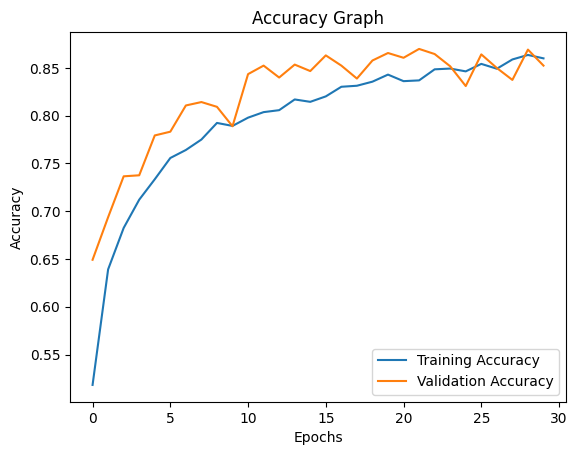

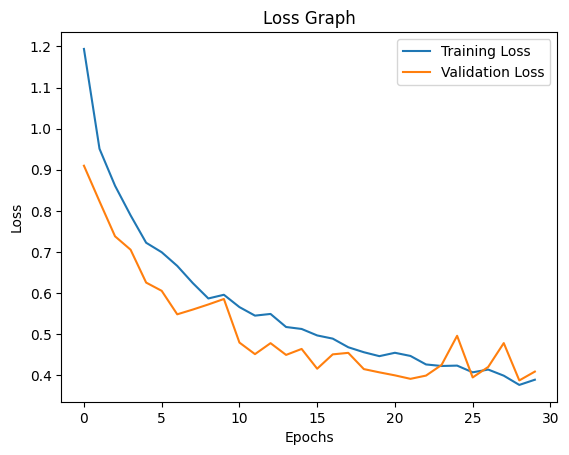

In [11]:
# Accuracy & Loss Graphs
# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()